In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
cru_data_pr=pd.read_excel('/content/cru-x0.5_timeseries.xlsx',sheet_name=0) # reading xlsx file uploaded to colab with 4 sheets
cru_data_tas=pd.read_excel('/content/cru-x0.5_timeseries.xlsx',sheet_name=1)
cru_data_tasmax=pd.read_excel('/content/cru-x0.5_timeseries.xlsx',sheet_name=2)
cru_data_tasmin=pd.read_excel('/content/cru-x0.5_timeseries.xlsx',sheet_name=3)

sheets_name=['pr','tas','tasmax','tasmin'] # sheet names
cru_data= [cru_data_pr,cru_data_tas,cru_data_tasmax,cru_data_tasmin] # total data list

for i in range(len(cru_data)): # display all datas
    print("Sheet:", sheets_name[i])
    display(cru_data[i])

Sheet: pr


,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,...,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,SYR,Syrian Arab Republic,217.07,350.09,252.73,351.37,300.44,356.04,348.28,342.7,...,298.45,197.63,370.27,380.62,326.59,237.42,277.85,299.11,291.59,182.98


Sheet: tas


,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,...,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,SYR,Syrian Arab Republic,17.89,17.47,16.7,17,17.17,17.31,16.83,16.78,...,19.19,19.12,19.98,19.31,19.42,19.75,19.23,19.8,19.83,19.93


Sheet: tasmax


,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,...,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,SYR,Syrian Arab Republic,25.23,24.61,23.5,23.78,23.96,24.11,23.62,23.76,...,26.26,26.24,26.79,26.09,26.35,26.79,26.04,26.66,26.64,27.05


Sheet: tasmin


,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,...,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,SYR,Syrian Arab Republic,10.61,10.38,9.95,10.27,10.43,10.56,10.08,9.86,...,12.16,12.05,13.21,12.59,12.54,12.76,12.45,12.99,13.06,12.85


this data is from year 1901 to 2025 in syria for prespartion , mean temperature , max temperature, and min temperature. from https://cckpapi.worldbank.org/api/v1/cru-x0.5_timeseries_tasmax,tas,pr_timeseries_annual_1901-2025_mean_historical_cru_ts4.10_mean/SYR?_format=json

In [54]:
for i in range(len(cru_data)):
    current = cru_data[i]# store the current sheet
    numerice = current.select_dtypes(include='number')# get just the number so that the describe function work properly
    print("----------------------------------------")
    print("SUMMARY FOR:", sheets_name[i])
    print("----------------------------------------")
    display(numerice.T.describe())# transpose so that i get 1 output per sheet instead of 125 copy paste items
    print("\n")

----------------------------------------
SUMMARY FOR: pr
----------------------------------------


,0
count,125.000000
mean,307.122720
std,57.451919
min,172.960000
25%,276.980000
50%,310.550000
75%,344.560000
max,451.220000




----------------------------------------
SUMMARY FOR: tas
----------------------------------------


,0
count,125.000000
mean,18.099040
std,0.778124
min,16.540000
25%,17.600000
50%,18.040000
75%,18.520000
max,20.320000




----------------------------------------
SUMMARY FOR: tasmax
----------------------------------------


,0
count,125.000000
mean,24.983280
std,0.810908
min,23.320000
25%,24.470000
50%,24.880000
75%,25.380000
max,27.330000




----------------------------------------
SUMMARY FOR: tasmin
----------------------------------------


,0
count,125.000000
mean,11.262960
std,0.793793
min,9.420000
25%,10.700000
50%,11.220000
75%,11.750000
max,13.360000


In [58]:
# some adational indecies
print("Top 5 Hottest Years (tas):") # gotest years by avrage temp
display(cru_data[1].loc[:, '1901-07':'2025-07'].iloc[0].nlargest(5))

print("\nTop 5 Driest Years (pr):") # Driest years by prespration
display(cru_data[0].loc[:, '1901-07':'2025-07'].iloc[0].nsmallest(5))

print("\n Cold peak (tasmin):") # Coldest years by min temp
display(cru_data[3].loc[:, '1901-07':'2025-07'].iloc[0].nsmallest(1))

print("\n temprutre  peak(tasmax):") # Warmest years by max temp
display(cru_data[2].loc[:, '1901-07':'2025-07'].iloc[0].nlargest(1))


Top 5 Hottest Years (tas):


,0
2010-07,20.32
2018-07,19.98
2025-07,19.93
2024-07,19.83
2023-07,19.80



Top 5 Driest Years (pr):


,0
1989-07,172.96
2025-07,182.98
2008-07,183.77
1999-07,184.58
1960-07,193.17



 Cold peak (tasmin):


,0
1911-07,9.42



 temprutre  peak(tasmax):


,0
2010-07,27.33


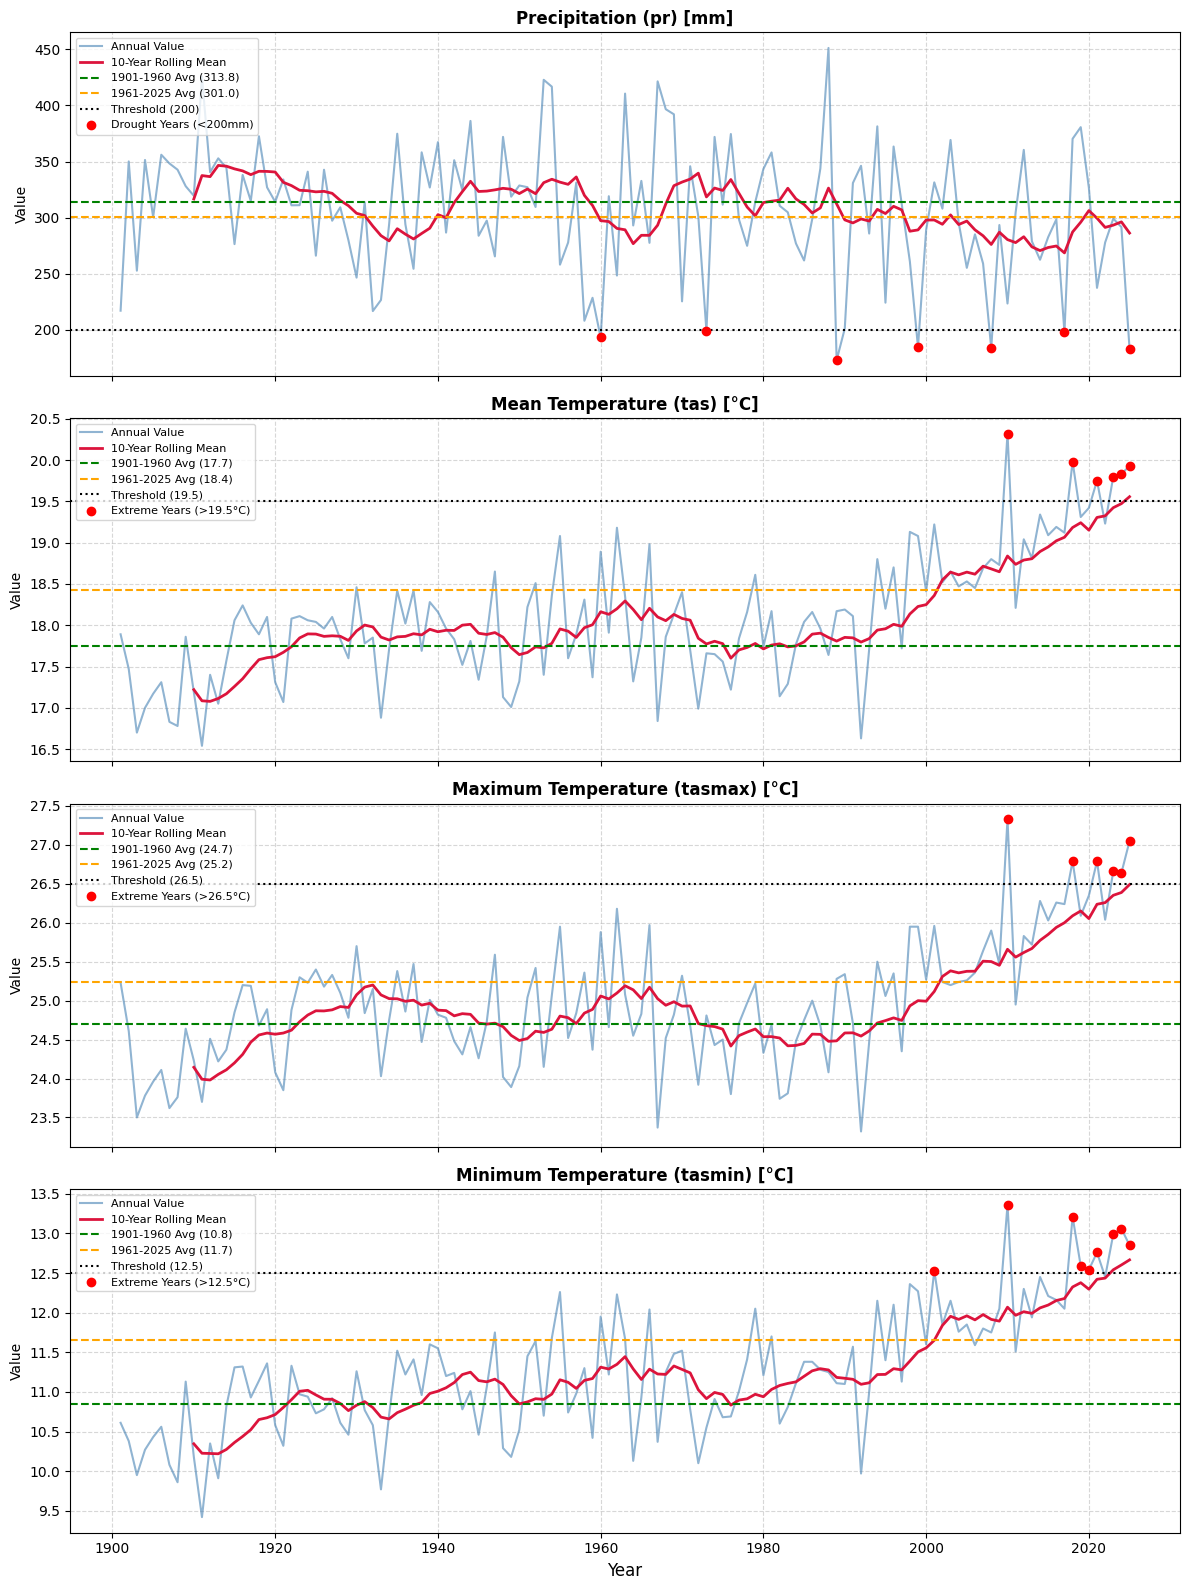

In [61]:
# here i used gemini free ai to plot
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

titles = {
    'pr': 'Precipitation (pr) [mm]',
    'tas': 'Mean Temperature (tas) [°C]',
    'tasmax': 'Maximum Temperature (tasmax) [°C]',
    'tasmin': 'Minimum Temperature (tasmin) [°C]'
}

thresholds = {
    'pr': 200,      # Drought threshold
    'tas': 19.5,    # Heat threshold
    'tasmax': 26.5,
    'tasmin': 12.5
}

# Calculate p1 and p2 (period averages)
p1 = {}
p2 = {}
for i, sheet_name_str in enumerate(sheets_name):
    df = cru_data[i]
    # Extract numerical columns for the periods
    period1_data = df.loc[0, '1901-07':'1960-07']
    period2_data = df.loc[0, '1961-07':'2025-07']
    p1[sheet_name_str] = period1_data.mean()
    p2[sheet_name_str] = period2_data.mean()


# Plotting loop
for idx, (ax, sheet_name_str) in enumerate(zip(axes, sheets_name)):
    current_df = cru_data[idx]

    # Extract the time series data (all years)
    series_raw = current_df.loc[0, '1901-07':'2025-07']

    # Convert index to integer years for plotting
    series = series_raw.copy()
    series.index = pd.to_datetime(series.index, format='%Y-%m').year

    # Line Plot & 10-Year Rolling Average
    ax.plot(series.index, series.values, color='steelblue', alpha=0.6, label='Annual Value')
    ax.plot(series.index, series.rolling(10).mean(), color='crimson', linewidth=2, label='10-Year Rolling Mean')

    # Period Comparison Lines
    ax.axhline(p1[sheet_name_str], color='green', linestyle='--', label=f'1901-1960 Avg ({p1[sheet_name_str]:.1f})')
    ax.axhline(p2[sheet_name_str], color='orange', linestyle='--', label=f'1961-2025 Avg ({p2[sheet_name_str]:.1f})')

    # Threshold Line & Highlighting
    thresh = thresholds[sheet_name_str]
    ax.axhline(thresh, color='black', linestyle=':', label=f'Threshold ({thresh})')

    if sheet_name_str == 'pr':
        extreme_years = series[series < thresh]
        ax.scatter(extreme_years.index, extreme_years.values, color='red', zorder=5, label='Drought Years (<200mm)')
    else:
        extreme_years = series[series > thresh]
        ax.scatter(extreme_years.index, extreme_years.values, color='red', zorder=5, label=f'Extreme Years (>{thresh}°C)')

    ax.set_title(titles[sheet_name_str], fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=8)

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

from these plots we find  that the temperutre in syria is in an upward trend  espacially in the last decade while the perspration is flacuating highly and the chance of drought becomeaning higher